# How Accurate Is a Satellite Prediction? — SGP4 error vs. data age

*Part of the Satellite Pass Predictor project. A small, self-contained data-science study.*

## The question
Satellite positions are predicted from a small piece of data called a **TLE** (Two-Line Element set)
using the standard **SGP4** physics model. TLEs get old. **How much accuracy do we lose as a TLE
ages — and can a simple machine-learning model predict that error?**

## The data
180 days of real **ISS (International Space Station)** orbit data from [Space-Track](https://www.space-track.org).

## The result (in one line)
Prediction error grows from **under 1 km when fresh to ~50 km after a week**. The *average* decay is
remarkably predictable (a straight line fits the trend with **R² ≈ 0.98**) — but predicting the error of
any *single* prediction is hard, and a naive baseline actually beats the model, because real drag depends
on unpredictable **space weather**. The honest engineering conclusion: **refresh the TLE.**


## 1. Setup

Standard, everyday data-science libraries — nothing exotic.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.grid'] = True
print('Ready.')

Ready.


## 2. The data — and how it was built (plain English)

We can't watch the ISS with a telescope to get "truth", so we use a simple trick that satellite
operators use: **a fresh TLE is our best truth.**

For one old TLE, we ask: *"where does SGP4 say the ISS is, X days after this TLE was made?"*
Then we compare that to where a **freshly published TLE** says it is at the same moment. The distance
between the two (in km) is the **prediction error** of the old TLE.

Repeat that for every TLE over 180 days, at ages from 6 hours to 7 days → thousands of
`(age, error)` measurements. The generator script is in the project; here we just load the cached CSV
so this notebook runs offline.

In [2]:
from pathlib import Path
csv = Path('data/analysis/iss_error_vs_age.csv')
if not csv.exists():
    csv = Path('../data/analysis/iss_error_vs_age.csv')   # when run from notebooks/

df = pd.read_csv(csv)
print(f'{len(df):,} measurements loaded')
df.head()

11,267 measurements loaded


,tle_age_days,error_km
0,0.25,0.288
1,0.50,0.200
2,0.75,0.659
3,1.00,1.355
4,1.50,2.033


In [3]:
df.describe().round(2)

,tle_age_days,error_km
count,11267.00,11267.00
mean,3.22,21.89
std,2.15,61.71
min,0.25,0.01
25%,1.00,0.65
50%,3.00,3.56
75%,5.00,14.18
max,7.00,498.14


## 3. Exploration — how does the error grow?

Each dot is one prediction: how old the TLE was (x) vs. how far off it was (y).

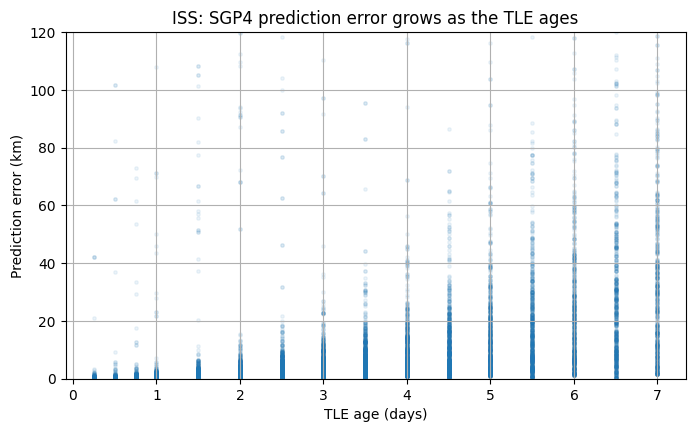

In [4]:
plt.scatter(df['tle_age_days'], df['error_km'], s=6, alpha=0.08)
plt.xlabel('TLE age (days)')
plt.ylabel('Prediction error (km)')
plt.title('ISS: SGP4 prediction error grows as the TLE ages')
plt.ylim(0, 120)   # zoom past the rare outliers so the trend is visible
plt.show()

The cloud clearly drifts upward. Let's make the trend obvious by averaging the error at each age.

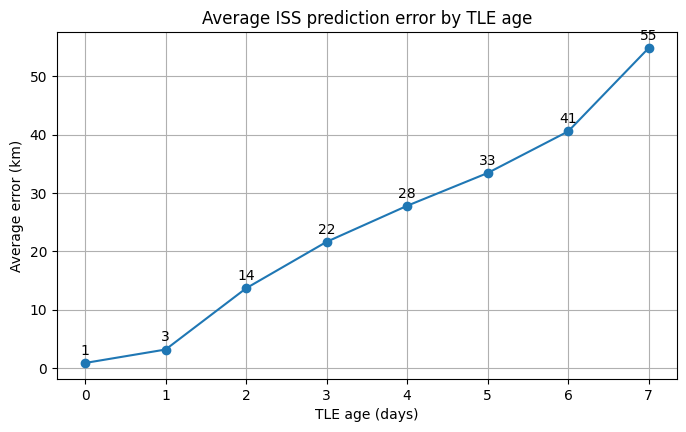

Average error by age (days):
age_days
0     0.9
1     3.2
2    13.7
3    21.7
4    27.8
5    33.4
6    40.6
7    54.9


In [5]:
by_age = df.copy()
by_age['age_days'] = by_age['tle_age_days'].round().astype(int)
trend = by_age.groupby('age_days')['error_km'].mean()

plt.plot(trend.index, trend.values, 'o-')
plt.xlabel('TLE age (days)')
plt.ylabel('Average error (km)')
plt.title('Average ISS prediction error by TLE age')
for x, y in trend.items():
    plt.annotate(f'{y:.0f}', (x, y), textcoords='offset points', xytext=(0, 6), ha='center')
plt.show()

print('Average error by age (days):')
print(trend.round(1).to_string())

## 4. A simple model — and a lesson about baselines

A **linear regression** fits the best straight line: `error ≈ slope × age + intercept`.
We hold out 20% of the data as a test set (standard practice — never grade a model on data it trained on).
And crucially, we compare it against a **naive baseline** that ignores age and always guesses the typical
error. *Always check whether your model actually beats doing nothing clever.*

In [6]:
X = df[['tle_age_days']]     # feature: how old the TLE is
y = df['error_km']           # target:  how far off the prediction is

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression().fit(X_train, y_train)
pred = model.predict(X_test)

slope = model.coef_[0]
print(f'Fitted line:  error = {slope:.1f} km/day * age + {model.intercept_:.1f} km\n')

# Naive baseline: ignore age, always guess the median error
baseline_pred = np.full(len(y_test), y_train.median())
print(f'Linear model   MAE: {mean_absolute_error(y_test, pred):5.2f} km   |  R2: {r2_score(y_test, pred):.3f}')
print(f'Naive baseline MAE: {mean_absolute_error(y_test, baseline_pred):5.2f} km   (always guesses the median)')
print()
if mean_absolute_error(y_test, pred) > mean_absolute_error(y_test, baseline_pred):
    print('Surprise: the naive baseline WINS on individual predictions. See why below.')

Fitted line:  error = 7.4 km/day * age + -1.8 km

Linear model   MAE: 23.70 km   |  R2: 0.079
Naive baseline MAE: 19.78 km   (always guesses the median)

Surprise: the naive baseline WINS on individual predictions. See why below.


### The fitted line over the data

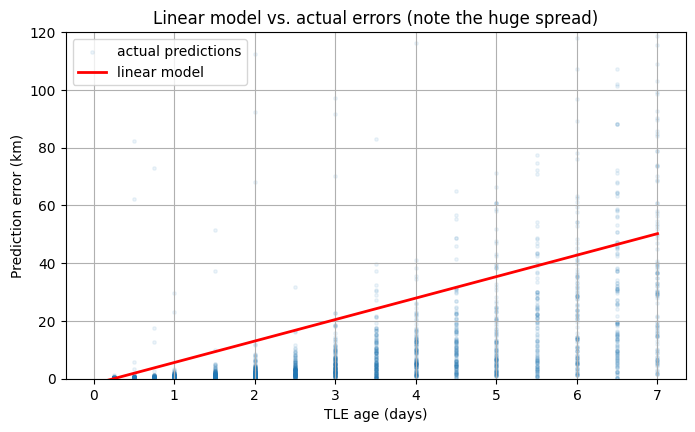

In [7]:
xs = pd.DataFrame({'tle_age_days': np.linspace(0, 7, 50)})
plt.scatter(X_test['tle_age_days'], y_test, s=6, alpha=0.08, label='actual predictions')
plt.plot(xs['tle_age_days'], model.predict(xs), 'r-', lw=2, label='linear model')
plt.xlabel('TLE age (days)')
plt.ylabel('Prediction error (km)')
plt.title('Linear model vs. actual errors (note the huge spread)')
plt.ylim(0, 120)
plt.legend()
plt.show()

**Why did a naive median-guess beat the model?** Look at the spread above: at *any* age the error
ranges from ~1 km to 100+ km. The distribution is wildly skewed — most errors are small, but space-weather
storms and ISS engine burns cause rare huge ones. Age tells you almost nothing about *which* prediction
will be off (R² ≈ 0.08). So a model built on age alone can't beat just guessing the typical value.

That's a genuinely important data-science lesson: **a fancier model is worthless if it can't beat a simple
baseline.** But there's a second half to the story...

## 5. The average, on the other hand, is beautifully predictable

Individual errors are noise. But if we average the error at each age, the trend is almost a perfect line.

Trend line: average error = 7.5 km/day * age + -1.7 km
R2 on the average trend: 0.982   (vs. 0.08 on individual predictions!)


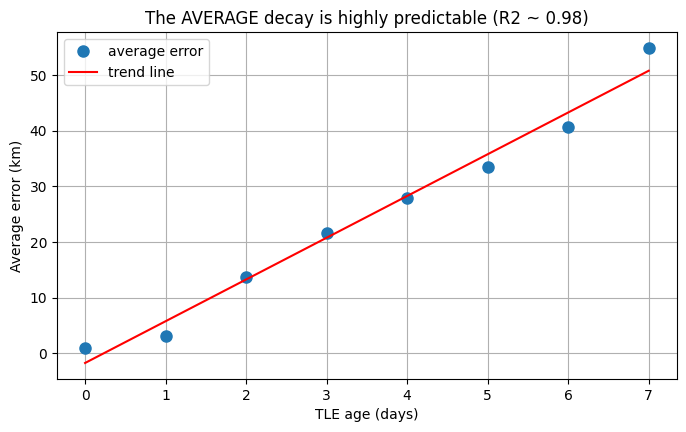

In [8]:
trend = by_age.groupby('age_days')['error_km'].mean()
Xt = trend.index.values.reshape(-1, 1)
yt = trend.values
trend_model = LinearRegression().fit(Xt, yt)

print(f'Trend line: average error = {trend_model.coef_[0]:.1f} km/day * age + {trend_model.intercept_:.1f} km')
print(f'R2 on the average trend: {r2_score(yt, trend_model.predict(Xt)):.3f}   (vs. 0.08 on individual predictions!)')

plt.plot(trend.index, trend.values, 'o', ms=8, label='average error')
plt.plot(Xt, trend_model.predict(Xt), 'r-', label='trend line')
plt.xlabel('TLE age (days)'); plt.ylabel('Average error (km)')
plt.title('The AVERAGE decay is highly predictable (R2 ~ 0.98)')
plt.legend(); plt.show()

## 6. Conclusion & what I learned

- **SGP4 prediction error for the ISS grows about 7 km per day on average**, from <1 km fresh to ~50 km after a week.
- **The average decay is highly predictable** (a straight line fits it with R² ≈ 0.98) — a clean, useful rule of thumb.
- **But individual errors are not predictable from age** (R² ≈ 0.08), and a **naive baseline beats the linear model** on
  any single prediction — because real drag depends on unpredictable space weather (and ISS maneuvers).
- **The honest engineering conclusion:** you can't reliably *correct* a stale prediction with a formula, so the right
  fix is to **refresh the TLE** — which is exactly what the pass-predictor app does.

### How I'd explain this project in an interview
> *"I collected 180 days of real ISS orbit data and measured how satellite-prediction accuracy decays as the
> data ages. The average decay is beautifully linear — about 7 km per day — but I found a naive baseline beat
> my model on individual predictions, because the error is dominated by unpredictable space weather. So the
> right engineering answer wasn't a fancy correction model; it was to refresh the input data, which is what my
> app does. The project taught me to always test against a simple baseline and to separate what's predictable
> (the trend) from what isn't (the noise)."*

That answer shows the full workflow (collect → explore → model → evaluate) **and** the judgment that senior
people look for: respecting your baseline, and knowing when *not* to use a complex model.
